In [1]:
from lib.evaluate import Eva
from lib.utils import read_parameters

import numpy as np
import plotly.express as px
import bioframe as bf
from tqdm import tqdm
import pandas as pd
from datetime import datetime
from collections import defaultdict
import upsetplot
import matplotlib.pyplot as plt

# Functions

In [2]:
def plot_precision_recall_curve(df, svtype):
    """ Plot precision recall curve. 

    param pr_rc_df: pandas dataframe with precision and recall for different thresholds """

    pr_rc_df = df[df['type'] == svtype].copy().reset_index(drop=True)
    pr_rc_df['method'] = pr_rc_df['method'].replace({'dicast' : 'MGI dicast', 
                                                     'delly' : 'MGI delly',
                                                     'manta' : 'MGI manta',
                                                     'lumpy' : 'MGI lumpy',
                                                     'gridss' : 'MGI gridss',
                                                     'cnvnator' : 'MGI cnvnator',
                                                     'sniffles' : 'PB sniffles'})

    colors = ['#50514F', '#F25F5C', '#F9A061', '#FFE066', '#A9D2DB', '#247BA0', '#67A2A0', '#50514F', '#F25F5C', '#F9A061', '#FFE066', '#A9D2DB']
    dash = ['solid', 'solid', 'solid', 'solid', 'solid', 'solid', 'solid', 'dot', 'dot', 'dot', 'dot', 'dot']
    fig = px.line(x='recall', y='precision', color='method', 
                data_frame=pr_rc_df, 
                color_discrete_sequence=colors,
                line_dash='method',
                line_dash_sequence=dash)

    for i, method in enumerate(pr_rc_df['method'].unique()):
        x = pr_rc_df[pr_rc_df['method'] == method].reset_index(drop=True).loc[0, 'recall']
        y = pr_rc_df[pr_rc_df['method'] == method].reset_index(drop=True).loc[0, 'precision']
        fig.add_shape(type='circle', xref='x', yref='y', x0=x-0.003, y0=y-0.015, x1=x+0.0025, y1=y+0.002, line_color=colors[i], line_width=2, opacity=1, fillcolor='white')

    fig.update_layout(plot_bgcolor='white', xaxis_title='Recall', yaxis_title='Precision', xaxis_linecolor='black', yaxis_linecolor='black')
    fig.update_traces(line=dict(width=2))
    fig.update_xaxes(ticks='outside', tickcolor='black', tickwidth=1, ticklen=5, gridcolor='lightgray', gridwidth=0.5, range=[0, 1])
    fig.update_yaxes(ticks='outside', tickcolor='black', tickwidth=1, ticklen=5, gridcolor='lightgray', gridwidth=0.5, range=[0, 1])
    fig.show()

In [3]:
def extract_overlap_ids(df1, df2):
    """ Extracts SV IDs of overlapping variants
    
    param df1: pandas dataframe, first dataframe
    param df2: pandas dataframe, second dataframe 
    
    return pandas dataframe with overlapping SV IDs """

    df1['end'] = df1['end'].astype(int)
    df2['end'] = df2['end'].astype(int)
    
    closest_intervals = bf.closest(df1, df2=df2, suffixes=('_1','_2'), k=50) # k=10 to get all overlapping variants
    closest_intervals = closest_intervals.dropna(subset=['id_1', 'id_2']).reset_index(drop=True)
    closest_intervals['diff_start'] = abs(closest_intervals['start_1'] - closest_intervals['start_2'])
    closest_intervals['diff_end'] = abs(closest_intervals['end_1'] - closest_intervals['end_2'])
    closest_intervals['diff_size'] = closest_intervals.apply(lambda x: min([x['size_1'], x['size_2']]) / max([x['size_1'], x['size_2']]), axis=1)

    overlapping_svs = closest_intervals[(closest_intervals['diff_start'] < 500) & (closest_intervals['diff_end'] < 500) & (closest_intervals['diff_size'] > 0.7)].copy()

    return overlapping_svs.reset_index(drop=True)

# Script

In [4]:
params = read_parameters('params/giab/params_eva.json')
params_ref = read_parameters('params/giab/params_prep_mgi.json')

In [5]:
eva = Eva(params, params_ref)
eva.read_benchmark_variants()
eva.correct_benchmark_variants()
eva.annotate_benchmark_variants()
eva.read_method_variants()
eva.read_dicast_variants()
eva.overlap_bench_dicast()
eva.overlap_bench_methods()
eva.filter_variants()
eva.create_multi_caller_support_table(methods=['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])
eva.compute_precision_recall_df(filtered=True)

In [47]:
pr_rc_dict = defaultdict(list)

for i in range(5):
    df = eva.variants_filtered['at least ' + str(i+1) + ' callers'].copy().reset_index(drop=True)
    tp = df[(df['confirmed'] == 1) & (df['qual'] > 0)].shape[0]
    fp = df[(df['confirmed'] == 0) & (df['qual'] > 0)].shape[0]
    fn = df[(df['confirmed'] == 1) & (df['qual'] == 0)].shape[0]

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    pr_rc_dict['method'].append('at least ' + str(i+1) + ' callers')
    pr_rc_dict['precision'].append(precision)
    pr_rc_dict['recall'].append(recall)

pr_rc_df = pd.DataFrame(pr_rc_dict)

In [71]:
eva.variants_filtered['dicast'].explode('id_dicast').merge(eva.variants_dicast[['id', 'filter', 'id_org']], left_on='id_dicast', right_on='id', how='left')

,id_x,chrom,start,end,type,size,confirmed,qual,id_dicast,cluster,cluster_start,cluster_end,id_y,filter,id_org
0,chr1-100817827-DEL-65,chr1,100817826,100817891,DEL,65.0,1,0.91,dicast.DEL.20179,NaN,NaN,NaN,dicast.DEL.20179,"LOW_QUAL, SINGLE_ASSEMBLY",gridss.DEL.1809
1,chr1-100922996-DEL-320,chr1,100922995,100923315,DEL,320.0,1,0.99,dicast.DEL.346,NaN,NaN,NaN,dicast.DEL.346,PASS,delly.DEL.346
2,chr1-100922996-DEL-320,chr1,100922995,100923315,DEL,320.0,1,0.99,dicast.DEL.10508,NaN,NaN,NaN,dicast.DEL.10508,PASS,manta.DEL.130
3,chr1-100922996-DEL-320,chr1,100922995,100923315,DEL,320.0,1,0.99,dicast.DEL.15029,NaN,NaN,NaN,dicast.DEL.15029,PASS,lumpy.DEL.93
4,chr1-100922996-DEL-320,chr1,100922995,100923315,DEL,320.0,1,0.99,dicast.DEL.20181,NaN,NaN,NaN,dicast.DEL.20181,PASS,gridss.DEL.1811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83377,dicast.DEL.73819,chrX,145494001,145496000,DEL,1999.0,0,0.00,dicast.DEL.73819,NaN,NaN,NaN,dicast.DEL.73819,PASS,cnvnator.DEL.2252
83378,dicast.DEL.73821,chrX,151912001,151921000,DEL,8999.0,0,0.00,dicast.DEL.73821,NaN,NaN,NaN,dicast.DEL.73821,PASS,cnvnator.DEL.2254
83379,dicast.DEL.73822,chrX,152118001,152121000,DEL,2999.0,0,0.00,dicast.DEL.73822,NaN,NaN,NaN,dicast.DEL.73822,PASS,cnvnator.DEL.2255
83380,dicast.DEL.73823,chrX,154637001,154647000,DEL,9999.0,0,0.00,dicast.DEL.73823,NaN,NaN,NaN,dicast.DEL.73823,PASS,cnvnator.DEL.2256


In [65]:
eva.variants_dicast

,id_org,sample,tech,method,type,chrom,chrom2,start,end,size,filter,qual,pred_dicast,qual_dicast,id
0,delly.DEL.1,HG002,mgi,delly,DEL,chr1,NaN,789418,224012416,223222998.0,PASS,61.0,0,0.00,dicast.DEL.1
1,delly.DEL.2,HG002,mgi,delly,DEL,chr1,NaN,790647,224015711,223225064.0,LowQual,72.0,0,0.00,dicast.DEL.2
2,delly.DEL.3,HG002,mgi,delly,DEL,chr1,NaN,791659,224013185,223221526.0,LowQual,3.0,0,0.00,dicast.DEL.3
3,delly.DEL.4,HG002,mgi,delly,DEL,chr1,NaN,820915,822678,1763.0,LowQual,6.0,0,0.08,dicast.DEL.4
4,delly.DEL.5,HG002,mgi,delly,DEL,chr1,NaN,820929,823302,2373.0,PASS,100.0,0,0.11,dicast.DEL.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73820,cnvnator.DEL.2254,HG002,mgi,cnvnator,DEL,chrX,NaN,151912001,151921000,8999.0,PASS,NaN,0,0.01,dicast.DEL.73821
73821,cnvnator.DEL.2255,HG002,mgi,cnvnator,DEL,chrX,NaN,152118001,152121000,2999.0,PASS,NaN,0,0.10,dicast.DEL.73822
73822,cnvnator.DEL.2256,HG002,mgi,cnvnator,DEL,chrX,NaN,154637001,154647000,9999.0,PASS,NaN,0,0.03,dicast.DEL.73823
73823,cnvnator.DEL.2257,HG002,mgi,cnvnator,DEL,chrX,NaN,155370001,155372000,1999.0,PASS,NaN,0,0.02,dicast.DEL.73824


In [59]:
eva.df_multi[['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'] == 0]

KeyError: False

In [62]:
eva.df_multi[(eva.df_multi['delly'] > 0) & (eva.df_multi[['manta', 'lumpy', 'gridss', 'cnvnator']] == 0).all(axis=1)]

,id,chrom,start,end,type,size,confirmed,cluster,cluster_start,cluster_end,delly,manta,lumpy,gridss,cnvnator
389,chr1-194381377-DEL-740,chr1,194381376,194382116,DEL,740.0,1,398.0,194381376.0,194382116.0,0.007965,0,0,0,0
421,chr1-207119029-DEL-736,chr1,207119028,207119764,DEL,736.0,1,430.0,207119028.0,207119764.0,0.025754,0,0,0,0
551,chr1-247128941-DEL-805,chr1,247128940,247129745,DEL,805.0,1,558.0,247128940.0,247129745.0,0.007201,0,0,0,0
564,chr1-248675030-DEL-906,chr1,248675029,248675935,DEL,906.0,1,570.0,248675018.0,248675935.0,0.014117,0,0,0,0
574,chr10-417697-DEL-409,chr10,417696,418105,DEL,409.0,1,579.0,417696.0,418105.0,0.00744,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12735,cnvnator.DEL.2254,chrX,151912001,151921000,DEL,8999.0,0,NaN,NaN,NaN,1.0,0,0,0,0
12736,cnvnator.DEL.2255,chrX,152118001,152121000,DEL,2999.0,0,NaN,NaN,NaN,1.0,0,0,0,0
12737,cnvnator.DEL.2256,chrX,154637001,154647000,DEL,9999.0,0,NaN,NaN,NaN,1.0,0,0,0,0
12738,cnvnator.DEL.2257,chrX,155370001,155372000,DEL,1999.0,0,NaN,NaN,NaN,1.0,0,0,0,0


In [35]:
pr_rc_df_long = pr_rc_df.melt(id_vars='method', value_vars=['precision', 'recall'], 
                  var_name='Metric', value_name='Value')

In [36]:
fig = px.bar(pr_rc_df_long, x='method', y='Value', color='Metric', barmode='group', color_discrete_sequence=['#F9A061', '#A9D2DB'])
fig.update_layout(plot_bgcolor='white')
fig.update_layout(yaxis=dict(showgrid=True, gridcolor='lightgray'))
fig.update_layout(bargap=0.5, width=800)
fig.show()

In [37]:
dicast_conf = eva.variants['dicast'][eva.variants['dicast']['confirmed'] == 1].copy().reset_index(drop=True)
dicast_conf = dicast_conf.explode('id_dicast')['id_dicast'].unique().tolist()[:-1]

In [38]:
for method in eva.variants_dicast['method'].unique():
    method_df = eva.variants_dicast[eva.variants_dicast['method'] == method].copy().reset_index(drop=True)
    method_df['confirmed'] = 0
    method_df.loc[method_df['id'].isin(dicast_conf), 'confirmed'] = 1
    mask_conf = (method_df['confirmed'] == 1) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    mask_not_conf = (method_df['confirmed'] == 0) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    print(method, method_df[mask_conf].shape[0], method_df[mask_not_conf].shape[0])

delly 97 28
manta 306 7
lumpy 0 0
gridss 1594 123
cnvnator 0 0


In [39]:
for method in eva.variants_dicast['method'].unique():
    method_df = eva.variants_dicast[eva.variants_dicast['method'] == method].copy().reset_index(drop=True)
    method_df['confirmed'] = 0
    method_df.loc[method_df['id'].isin(dicast_conf), 'confirmed'] = 1
    mask_conf = (method_df['confirmed'] == 1) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    mask_not_conf = (method_df['confirmed'] == 0) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    print(method, method_df[mask_conf].shape[0], method_df[mask_not_conf].shape[0])

delly 97 28
manta 306 7
lumpy 0 0
gridss 1594 123
cnvnator 0 0


In [40]:
methods = ['delly', 'manta', 'lumpy', 'gridss', 'cnvnator']
result_dict = defaultdict(list)
for i in range(len(methods)):
    for j in range(i+1, len(methods)):
        method1 = methods[i]
        method2 = methods[j]
        mask_int = (eva.df_multi[method1] != 0) & (eva.df_multi[method2] != 0)
        mask_un = (eva.df_multi[method1] != 0) | (eva.df_multi[method2] != 0)
        
        for method in methods:
            result_dict[method].append(False)
        result_dict[method1][-1] = True
        result_dict[method2][-1] = True
        result_dict['jaccard'].append(eva.df_multi[mask_int].shape[0] / eva.df_multi[mask_un].shape[0])

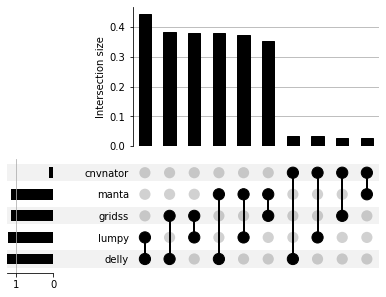

In [42]:
from upsetplot import plot
plot(pd.DataFrame(result_dict).set_index(['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])['jaccard'])  
plt.savefig('upset.png', dpi=300, bbox_inches='tight')

In [19]:
m = ['delly', 'manta', 'lumpy', 'gridss', 'cnvnator']
tmp = eva.df_multi[(eva.df_multi[m] > 0).sum(axis=1) == 1]
unique_calls = dict()
for method in m:
    df_method = tmp[tmp[method] > 0].copy().reset_index(drop=True)
    #df_method = df_method.merge(eva.variants_dicast[['id_org', 'filter', 'qual_dicast']], left_on='id', right_on='id_org', how='left')
    unique_calls[method] = df_method['id']